<a href="https://colab.research.google.com/github/DavidRR95/Fina/blob/main/Copia_de_Analisis_de_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MBA 2025 - Indices Accionarios - Riesgo y Retorno

Profesor Fernando Díaz H.

In [ ]:
install.packages("tidyquant")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘globals’, ‘listenv’, ‘parallelly’, ‘mvtnorm’, ‘pcaPP’, ‘DEoptimR’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘furrr’, ‘crosstalk’, ‘warp’, ‘BH’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘tseries’, ‘urca’, ‘RcppArmadillo’, ‘RcppRoll’, ‘future’, ‘quadprog’, ‘pyinit’, ‘rrcov’, ‘robustbase’, ‘recipes’, ‘rsample’, ‘plotly’, ‘padr’, ‘slider’, ‘anytime’, ‘forecast’, ‘tsfeatures’, ‘lazyeval’, ‘PerformanceAnalytics’, ‘RobStatTM’, ‘quantmod’, ‘timetk’, ‘timeDate’, ‘TTR’, ‘xts’, ‘zoo’




In [ ]:
library(tidyquant) # To download the data
library(timetk) # To manipulate the data series
library(tidyr)
library(ggplot2)
library(forcats)
library(dplyr)

ERROR: Error in library(tidyquant): there is no package called ‘tidyquant’


# I Extraer Datos Bursátiles

## Data

Vamos a extraer información bursátil de las siguientes acciones:

* Apple Inc (AAPL);
* Wallmart (WMT);
* Intel (INTC)
* Exxon (XOM)
* L-M (LMT)


In [ ]:

tick <- c('AAPL', 'WMT', 'INTC', 'XOM', 'LMT')

In [ ]:
tick

[1] "AAPL" "WMT"  "INTC" "XOM"  "LMT"

 El paquete **tidyquant** es una herramienta para trabajar con datos financieros y análisis cuantitativos en el entorno **tidyverse**.

 La función **tq_get** se utiliza para extraer datos financieros directamente al entorno de R. Vamos a estraer los datos de las acciones para el período de 5 años que terminó ayer y las vamos a guardar en el objeto *price_data*:

In [ ]:
price_data <- tq_get(tick,
                     from = '2020-01-01',
                     to = '2024-12-31',
                     get = 'stock.prices')

In [ ]:
class(price_data)
price_data

[1] "tbl_df"     "tbl"        "data.frame"

symbol,date,open,high,low,close,volume,adjusted
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAPL,2020-01-02,74.0600,75.1500,73.7975,75.0875,135480400,72.53851
AAPL,2020-01-03,74.2875,75.1450,74.1250,74.3575,146322800,71.83329
AAPL,2020-01-06,73.4475,74.9900,73.1875,74.9500,118387200,72.40567
AAPL,2020-01-07,74.9600,75.2250,74.3700,74.5975,108872000,72.06516
AAPL,2020-01-08,74.2900,76.1100,74.2900,75.7975,132079200,73.22443
AAPL,2020-01-09,76.8100,77.6075,76.5500,77.4075,170108400,74.77976
AAPL,2020-01-10,77.6500,78.1675,77.0625,77.5825,140644800,74.94881
AAPL,2020-01-13,77.9100,79.2675,77.7875,79.2400,121532000,76.55006
AAPL,2020-01-14,79.1750,79.3925,78.0425,78.1700,161954400,75.51636


## Retornos Diarios

A continuación, calcularemos la rentabilidad diaria de estos valores. Utilizaremos los rendimientos logarítmicos y guardaremos la información en el objeto *log_red_tidy*:


In [ ]:
log_ret_tidy <- price_data %>%
  group_by(symbol) %>%
  tq_transmute(select = adjusted,
               mutate_fun = periodReturn,
               period = 'daily',
               col_rename = 'ret',
               type = 'log')

In [ ]:
log_ret_tidy

symbol,date,ret
<chr>,<date>,<dbl>
AAPL,2020-01-02,0.000000000
AAPL,2020-01-03,-0.009769618
AAPL,2020-01-06,0.007936595
AAPL,2020-01-07,-0.004713973
AAPL,2020-01-08,0.015958417
AAPL,2020-01-09,0.021018233
AAPL,2020-01-10,0.002258014
AAPL,2020-01-13,0.021139556
AAPL,2020-01-14,-0.013595572


El operador %>% (**pipe operator**) es una característica poderosa del paquete **dplyr** que  permite encadenar secuencialmente varias operaciones en un flujo de trabajo de análisis de datos. Esto hace que el código sea más legible, ya que las operaciones se ejecutan de izquierda a derecha, pasando el resultado de la operación anterior como el primer argumento de la siguiente operación.

La función **group_by()** se usa para agrupar los datos en un marco de datos según una o varias variables.

 La función **tq_transmute** se utiliza para transformar y resumir datos financieros



In [ ]:
head(log_ret_tidy)

symbol,date,ret
<chr>,<date>,<dbl>
AAPL,2020-01-02,0.000000000
AAPL,2020-01-03,-0.009769618
AAPL,2020-01-06,0.007936595
AAPL,2020-01-07,-0.004713973
AAPL,2020-01-08,0.015958417
AAPL,2020-01-09,0.021018233


## Formato "Ancho"

La función **pivot_wider** es parte del paquete **tidyr** en R y se utiliza para transformar datos de formato largo a formato ancho, creando nuevas columnas basadas en valores únicos en una columna y llenando esas columnas con valores de otra columna.

In [ ]:
log_ret_xts <- log_ret_tidy %>%
  pivot_wider(names_from = symbol, values_from =ret) %>%
  tk_xts()

head(log_ret_xts)

Warning message:
“Non-numeric columns being dropped: date”
Using column `date` for date_var.



                   AAPL          WMT          INTC          XOM          LMT
2020-01-02  0.000000000  0.000000000  0.0000000000  0.000000000  0.000000000
2020-01-03 -0.009769618 -0.008866954 -0.0122377001 -0.008071947  0.035349304
2020-01-06  0.007936595 -0.002038257 -0.0028324133  0.007648606 -0.001523814
2020-01-07 -0.004713973 -0.009308095 -0.0168271267 -0.008217677  0.003359063
2020-01-08  0.015958417 -0.003437444  0.0006786583 -0.015195352 -0.008406642
2020-01-09  0.021018233  0.010277508  0.0055804234  0.007626574  0.009443588

Ahora sí tenemos los datos como los necesitamos.

# II Estadísticos Requeridos

## Rentabilidad media diaria de cada activo.

In [ ]:
mean_ret <- colMeans(log_ret_xts)
print(round(mean_ret, 5))

    AAPL      WMT     INTC      XOM      LMT 
 0.00099  0.00072 -0.00079  0.00051  0.00026 


## Varianzas y Covarianzas

Calcularemos la matriz de covarianzas de todas estas acciones y las anualizaremos multiplicándola por 252.

In [ ]:
cov_mat <- cov(log_ret_xts)*252

print(round(cov_mat,4))

       AAPL    WMT   INTC    XOM    LMT
AAPL 0.1002 0.0260 0.0680 0.0314 0.0264
WMT  0.0260 0.0510 0.0265 0.0140 0.0182
INTC 0.0680 0.0265 0.1955 0.0435 0.0286
XOM  0.0314 0.0140 0.0435 0.1182 0.0379
LMT  0.0264 0.0182 0.0286 0.0379 0.0685


# III Single Portfolio

Para calcular la rentabilidad de la cartera y el riesgo (desviación típica) necesitaremos:

* Rentabilidad media de los activos
* Ponderaciones del portfolio
* Matriz de covarianza de todos los activos


## Ponderaciones Aleatorias

La función **runif** es una función incorporada en R que se utiliza para generar números aleatorios según una distribución uniforme.

In [ ]:
wts <- runif(n = length(tick), min = 0, max = 1)
wts <- wts/sum(wts)
print(wts)
print(sum(wts))

[1] 0.05671424 0.10516666 0.26830422 0.27936077 0.29045411
[1] 1


## Retornos y Riesgo Anualizados


$E\left[\tilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}E\left[\tilde{r}_{i}\right]$

$Var\left[\tilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}^{2}\sigma_{ii}+\underset{i\neq j}{\sum_{i=1}^{N}\sum_{j=1}^{N}w_{i}w_{j}\sigma_{ij}}=\sum_{i=1}^{N}\sum_{j=1}^{N}w_{i}w_{j}\sigma_{ij}$


$
E\left[\tilde{r}_{p}\right]=\left[E\left[\tilde{r}_{1}\right]\,E\left[\tilde{r}_{2}\right]\,...\,E\left[\tilde{r}_{N}\right]\right]\left[\begin{array}{c}
w_{1}\\
w_{2}\\
\vdots\\
w_{N}
\end{array}\right]=R'W
$
$
Var\left[\tilde{r}_{p}\right]=\left[w_{1}\,w_{2}\,...\,w_{N}\right]\left[\begin{array}{cccc}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1N}\\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
\sigma_{N1} & \sigma_{N2} & \cdots & \sigma_{NN}
\end{array}\right]\left[\begin{array}{c}
w_{1}\\
w_{2}\\
\vdots\\
w_{N}
\end{array}\right]=W'\Sigma W
$




In [ ]:
port_returns <- (sum(wts * mean_ret) + 1)^252 - 1
print(port_returns)

port_risk <- sqrt(t(wts) %*% (cov_mat %*% wts))
print(port_risk)

[1] 0.0350242
          [,1]
[1,] 0.2340055


## Sharpe Ratio

Necesitamos la tasa libre de riesgo en USA: http://www.worldgovernmentbonds.com/

In [ ]:
rf <- 0.04413

sharpe_ratio <- (port_returns-rf)/port_risk
print(sharpe_ratio)

            [,1]
[1,] -0.03891274


# IV Randomizando sobre N Portfolios

OK. Primero debemos definir cuántos portfolios queremos en el gráfico. Vamos a crear también el objeto *all_wts* para almacenar los datos:

In [ ]:
num_port <- 50000
all_wts <- matrix(nrow = num_port,
                  ncol = length(tick))

Tenemos que:
* Crear  un vector vacío para almacenar los retornos de cada cartera - **port_returns**
* Crear un vector vacío para almacenar la  desviación estándar de cada cartera - **port_risk**
* Crear un vector vacío para almacenar el  ratio de Sharpe de cada cartera - **sharpe_ratio**

In [ ]:
port_returns <- vector('numeric', length = num_port)
port_risk <- vector('numeric', length = num_port)
sharpe_ratio <- vector('numeric', length = num_port)


Ahora, con un comando *for*, vamos a ir llenando cada uno de estos vectores con los resultados de repetir (III) tantas veces como portfolios queremos (**num_port**). Para esto debemos **indexar** las matrices o vectores.

Por ejemplo, para acceder al elemento en la segunda fila y tercera columna escribimos *mat[2,3]*.

Para acceder a la segunda fila completa, escribimos *mat[2, ]*.

In [ ]:
for (i in seq_along(port_returns)) {

  wts <- runif(length(tick))
  wts <- wts/sum(wts)

  # Storing weight in the matrix
  all_wts[i,] <- wts

  # Portfolio returns

  port_ret <- sum(wts * mean_ret)
  port_ret <- ((port_ret + 1)^252) - 1

  # Storing Portfolio Returns values
  port_returns[i] <- port_ret


  # Creating and storing portfolio risk
  port_sd <- sqrt(t(wts) %*% (cov_mat  %*% wts))
  port_risk[i] <- port_sd

  # Creating and storing Portfolio Sharpe Ratios
  # Assuming 0% Risk free rate

  sr <- (port_ret-rf)/port_sd
  sharpe_ratio[i] <- sr

}

Y guardamos los resultados en una tabla (**tibble**):

In [ ]:
portfolio_values <- tibble(Return = port_returns,
                           Risk = port_risk,
                           SharpeRatio = sharpe_ratio)

In [ ]:
head(portfolio_values)

Return,Risk,SharpeRatio
<dbl>,<dbl>,<dbl>
0.14307213,0.2098764,0.47143056
0.06143293,0.2379384,0.07272024
0.10765102,0.2018490,0.31469568
0.13054618,0.2222886,0.38875675
0.11075521,0.2341013,0.28459986
0.07204127,0.2455745,0.11365707


Ahora queremos pegar los pesos de cada portfolio a la tabla que acabamos de crear.

In [ ]:
all_wts <- tk_tbl(all_wts)

Warning message in tk_tbl.data.frame(as.data.frame(data), preserve_index, rename_index, :
“Warning: No index to preserve. Object otherwise converted to tibble successfully.”


In [ ]:
head(all_wts)
class(all_wts)

V1,V2,V3,V4,V5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.3306892,0.15411400,0.07061011,0.13666245,0.30792423
0.1145133,0.08740966,0.22662971,0.36694729,0.20450005
0.2029935,0.31712528,0.14830487,0.03839117,0.29318521
0.2568391,0.22822804,0.13908007,0.32701414,0.04883864
0.3332882,0.34381440,0.24490565,0.05899958,0.01899219
0.3254210,0.05235556,0.26996320,0.15756355,0.19469665


[1] "tbl_df"     "tbl"        "data.frame"

Las columnas corresponden a los pesos en cada una de las acciones. Pongámosle nombre:

In [ ]:
colnames(all_wts) <- colnames(log_ret_xts)
head(all_wts)

AAPL,WMT,INTC,XOM,LMT
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.3306892,0.15411400,0.07061011,0.13666245,0.30792423
0.1145133,0.08740966,0.22662971,0.36694729,0.20450005
0.2029935,0.31712528,0.14830487,0.03839117,0.29318521
0.2568391,0.22822804,0.13908007,0.32701414,0.04883864
0.3332882,0.34381440,0.24490565,0.05899958,0.01899219
0.3254210,0.05235556,0.26996320,0.15756355,0.19469665


Finalmente, juntamos ambas tablas con el comando **cbind**

In [ ]:
portfolio_values <- cbind(all_wts, portfolio_values)
head(portfolio_values)

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3306892,0.15411400,0.07061011,0.13666245,0.30792423,0.14307213,0.2098764,0.47143056
2,0.1145133,0.08740966,0.22662971,0.36694729,0.20450005,0.06143293,0.2379384,0.07272024
3,0.2029935,0.31712528,0.14830487,0.03839117,0.29318521,0.10765102,0.2018490,0.31469568
4,0.2568391,0.22822804,0.13908007,0.32701414,0.04883864,0.13054618,0.2222886,0.38875675
5,0.3332882,0.34381440,0.24490565,0.05899958,0.01899219,0.11075521,0.2341013,0.28459986
6,0.3254210,0.05235556,0.26996320,0.15756355,0.19469665,0.07204127,0.2455745,0.11365707


¡Esto es justamente lo que queríamos!

# V Gráficos

## El Portfolio de Mínima Varianza

In [ ]:
min_var <- portfolio_values[which.min(portfolio_values$Risk),]
min_var

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12706,0.1153318,0.4891651,0.009518371,0.1168643,0.2691205,0.1591845,0.1869692,0.6153661


Ahora graficamos usando **ggplot**

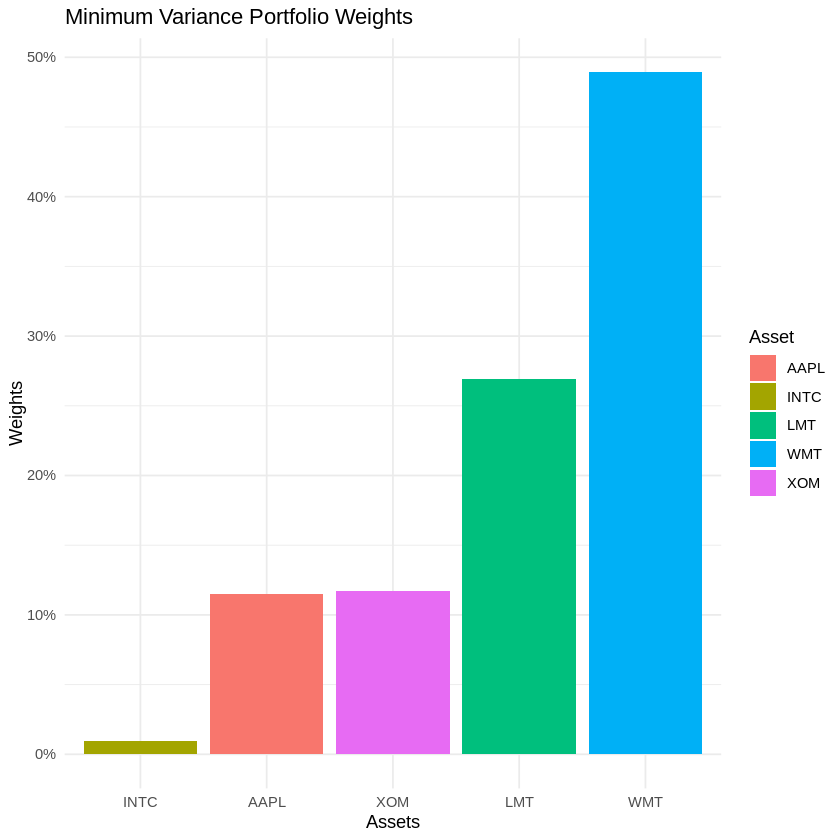

In [ ]:

p <- min_var %>%
  gather(all_of(tick), key = Asset,
         value = Weights) %>%
  mutate(Asset = as.factor(Asset)) %>%
  ggplot(aes(x = fct_reorder(Asset,Weights), y = Weights, fill = Asset)) +
  geom_bar(stat = 'identity') +
  theme_minimal() +
  labs(x = 'Assets', y = 'Weights', title = "Minimum Variance Portfolio Weights") +
  scale_y_continuous(labels = scales::percent)

p

## El Portfolio de Tangencia

In [ ]:
max_sr <- portfolio_values[which.max(portfolio_values$SharpeRatio),]
max_sr

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
29159,0.3853632,0.4937346,0.0009593978,0.1194831,0.0004597237,0.2218136,0.2086035,0.8517765


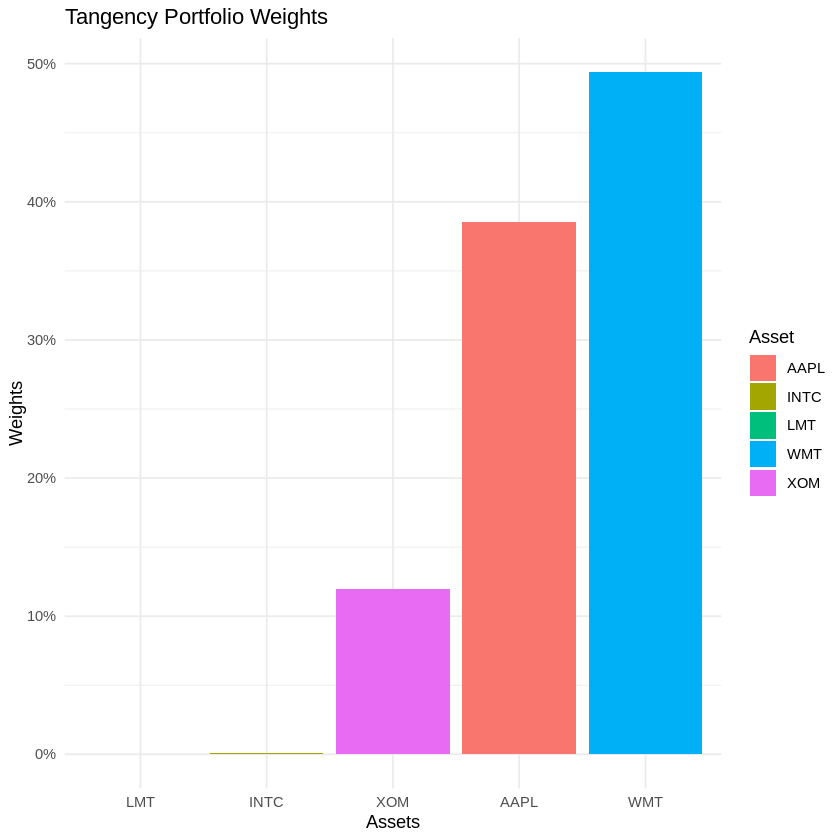

In [ ]:
p <- max_sr %>%
  gather(all_of(tick), key = Asset,
         value = Weights) %>%
  mutate(Asset = as.factor(Asset)) %>%
  ggplot(aes(x = fct_reorder(Asset,Weights), y = Weights, fill = Asset)) +
  geom_bar(stat = 'identity') +
  theme_minimal() +
  labs(x = 'Assets', y = 'Weights', title = "Tangency Portfolio Weights") +
  scale_y_continuous(labels = scales::percent)
p

## La Frontera Eficiente

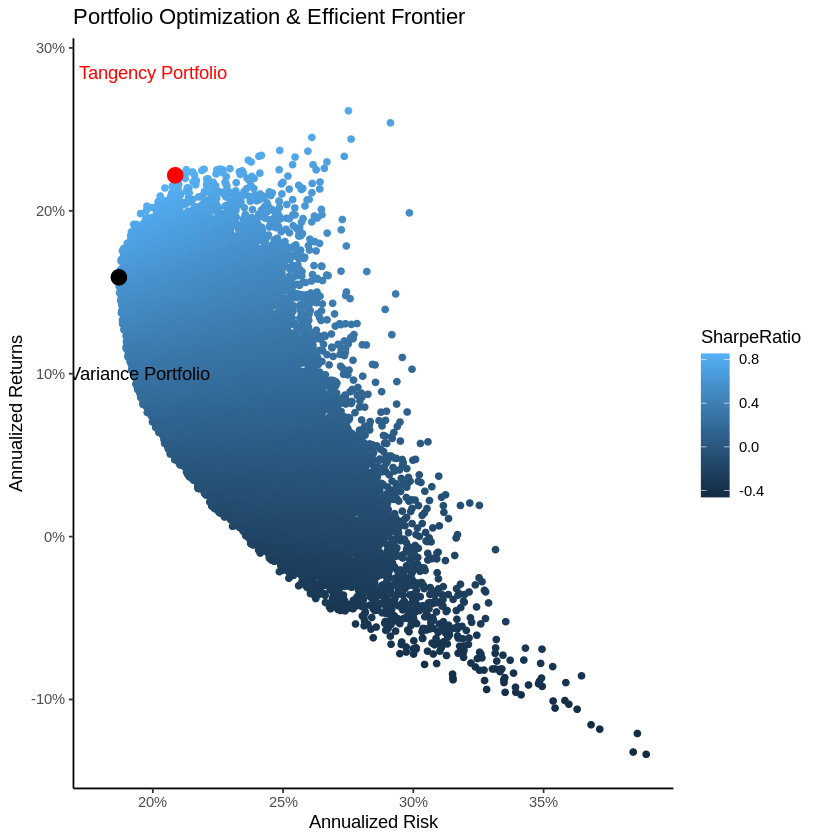

In [ ]:

p <- portfolio_values %>%
  ggplot(aes(x = Risk, y = Return, color = SharpeRatio)) +
  geom_point() +
  theme_classic() +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(labels = scales::percent) +
  labs(x = 'Annualized Risk',
       y = 'Annualized Returns',
       title = "Portfolio Optimization & Efficient Frontier") +
  geom_point(aes(x = Risk,
                 y = Return), data = min_var, color = 'black',size=4) +
  geom_point(aes(x = Risk,
                 y = Return), data = max_sr, color = 'red',size=4) +
  annotate('text', x = 0.20, y = 0.285, label = "Tangency Portfolio",
           color = 'red') +
  annotate('text', x = 0.18, y = 0.10, label = "Minimum Variance Portfolio",
           color = 'black')
p

In [ ]:
p <- portfolio_values %>%
  ggplot(aes(x = Risk, y = Return, color = SharpeRatio)) +
  geom_point() +
  theme_classic() +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(labels = scales::percent) +
  labs(x = 'Annualized Risk',
       y = 'Annualized Returns',
       title = "Portfolio Optimization & Efficient Frontier") +
  geom_point(aes(x = Risk,
                 y = Return), data = min_var, color = 'black', size = 4) +
  geom_point(aes(x = Risk,
                 y = Return), data = max_sr, color = 'red', size = 4) +
  geom_label(aes(x = 0.20, y = 0.285, label = "Tangency Portfolio"),
             color = 'red', fill = 'white', label.size = 0.25) +
  geom_label(aes(x = 0.18, y = 0.10, label = "Minimum Variance Portfolio"),
             color = 'black', fill = 'white', label.size = 0.25)


p


Warning message in geom_label(aes(x = 0.2, y = 0.285, label = "Tangency Portfolio"), :
“All aesthetics have length 1, but the data has 100000 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
Warning message in geom_label(aes(x = 0.18, y = 0.1, label = "Minimum Variance Portfolio"), :
“All aesthetics have length 1, but the data has 100000 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


Y si lo queremos grabar:

In [ ]:
ggsave(p, file="Frontera_Ef.png", device=cairo_ps,width=10, height=5)